<a href="https://colab.research.google.com/github/Nazqia/Bab-5/blob/second/Bab_5_Nazqia_salwa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

In [10]:
flowers_path = "/content/data/flowers"
bike_path = "/content/data/bike"
cars_path = "/content/data/cars"
horses_path = "/content/data/horses"
human_path = "/content/data/human"
cats_path = "/content/data/cats"
dogs_path = "/content/data/dogs"

flowers_filenames = os.listdir(flowers_path)
bike_filenames = os.listdir(bike_path)
cars_filenames = os.listdir(cars_path)
horses_filenames = os.listdir(horses_path)
human_filenames = os.listdir(human_path)
cats_filenames = os.listdir(cats_path)
dogs_filenames = os.listdir(dogs_path)

In [4]:
!unzip archive.zip

Archive:  archive.zip
  inflating: data/bike/bike_001.bmp  
  inflating: data/bike/bike_002.bmp  
  inflating: data/bike/bike_003.bmp  
  inflating: data/bike/bike_004.bmp  
  inflating: data/bike/bike_005.bmp  
  inflating: data/bike/bike_006.bmp  
  inflating: data/bike/bike_007.bmp  
  inflating: data/bike/bike_008.bmp  
  inflating: data/bike/bike_009.bmp  
  inflating: data/bike/bike_010.bmp  
  inflating: data/bike/bike_011.bmp  
  inflating: data/bike/bike_012.bmp  
  inflating: data/bike/bike_013.bmp  
  inflating: data/bike/bike_014.bmp  
  inflating: data/bike/bike_015.bmp  
  inflating: data/bike/bike_016.bmp  
  inflating: data/bike/bike_017.bmp  
  inflating: data/bike/bike_018.bmp  
  inflating: data/bike/bike_019.bmp  
  inflating: data/bike/bike_020.bmp  
  inflating: data/bike/bike_021.bmp  
  inflating: data/bike/bike_022.bmp  
  inflating: data/bike/bike_023.bmp  
  inflating: data/bike/bike_024.bmp  
  inflating: data/bike/bike_025.bmp  
  inflating: data/bike/bike_

In [9]:
!find /content -maxdepth 3 -type d

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.05.12
/content/.config/configurations
/content/.ipynb_checkpoints
/content/data
/content/data/flowers
/content/data/bike
/content/data/cars
/content/data/horses
/content/data/human
/content/data/cats
/content/data/data
/content/data/data/flowers
/content/data/data/bike
/content/data/data/cars
/content/data/data/horses
/content/data/data/human
/content/data/data/cats
/content/data/data/dogs
/content/data/dogs
/content/sample_data


In [11]:
flowers_filenames

['0036.png',
 '0179.png',
 '0041.png',
 '0208.png',
 '0132.png',
 '0107.png',
 '0063.png',
 '0084.png',
 '0089.png',
 '0034.png',
 '0005.png',
 '0071.png',
 '0167.png',
 '0079.png',
 '0031.png',
 '0191.png',
 '0080.png',
 '0037.png',
 '0190.png',
 '0170.png',
 '0068.png',
 '0078.png',
 '0028.png',
 '0064.png',
 '0074.png',
 '0075.png',
 '0135.png',
 '0128.png',
 '0049.png',
 '0117.png',
 '0138.png',
 '0021.png',
 '0003.png',
 '0090.png',
 '0187.png',
 '0140.png',
 '0093.png',
 '0175.png',
 '0154.png',
 '0143.png',
 '0162.png',
 '0104.png',
 '0001.png',
 '0171.png',
 '0103.png',
 '0207.png',
 '0174.png',
 '0094.png',
 '0206.png',
 '0116.png',
 '0087.png',
 '0044.png',
 '0147.png',
 '0189.png',
 '0157.png',
 '0139.png',
 '0180.png',
 '0096.png',
 '0113.png',
 '0118.png',
 '0112.png',
 '0141.png',
 '0186.png',
 '0185.png',
 '0201.png',
 '0203.png',
 '0163.png',
 '0173.png',
 '0196.png',
 '0046.png',
 '0123.png',
 '0155.png',
 '0023.png',
 '0125.png',
 '0026.png',
 '0149.png',
 '0114.png',

In [12]:
def load_image(filenames, path):
    images = []
    for filename in tqdm(filenames):
        image = cv2.imread(path + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)

    return images

In [13]:
flowers_images = load_image(flowers_filenames, flowers_path)
bike_images = load_image(bike_filenames, bike_path)
cars_images = load_image(cars_filenames, cars_path)
horses_images = load_image(horses_filenames, horses_path)
human_images = load_image(human_filenames, human_path)
cats_images = load_image(cats_filenames, cats_path)
dogs_images = load_image(dogs_filenames, dogs_path)

100%|██████████| 202/202 [00:00<00:00, 561.74it/s]


In [14]:
heights = []
widths = []

for image in flowers_images:
    height = image.shape[0]
    width = image.shape[1]

    heights.append(height)
    widths.append(width)

print('max_h: {}, min_h: {}'.format(max(heights), min(heights)))
print('max_w: {}, min_w: {}'.format(max(widths), min(widths)))

max_h: 208, min_h: 128
max_w: 208, min_w: 128


In [19]:
def resize_images(images_list):
    new_images = []

    for image in images_list:
        resized = cv2.resize(image, (80, 80))
        new_images.append(resized)

    return np.array(new_images)

In [22]:
flowers_80 = resize_images(flowers_images)
bike_80 = resize_images(bike_images)
cars_80 = resize_images(cars_images)
horses_80 = resize_images(horses_images)
human_80 = resize_images(human_images)
cats_80 = resize_images(cats_images)
dogs_80 = resize_images(dogs_images)

In [23]:
print(flowers_80.shape)
print(bike_80.shape)
print(cars_80.shape)
print(horses_80.shape)
print(human_80.shape)
print(cats_80.shape)
print(dogs_80.shape)

(210, 80, 80)
(365, 80, 80)
(420, 80, 80)
(202, 80, 80)
(202, 80, 80)
(202, 80, 80)
(202, 80, 80)


In [24]:
all_images = np.concatenate([
    flowers_80,
    bike_80,
    cars_80,
    horses_80,
    human_80,
    cats_80,
    dogs_80
], axis=0)

all_images.shape

(1803, 80, 80)

In [25]:
all_images = all_images.reshape(all_images.shape[0],
                                all_images.shape[1],
                                all_images.shape[2],
                                1)

all_images.shape

(1803, 80, 80, 1)

In [26]:
labels = (
    [0] * len(flowers_80) +
    [1] * len(bike_80) +
    [2] * len(cars_80) +
    [3] * len(horses_80) +
    [4] * len(human_80) +
    [5] * len(cats_80) +
    [6] * len(dogs_80)
)

len(labels)

1803

In [27]:
X_train, X_test, y_train, y_test = train_test_split(all_images,
                                                    labels,
                                                    test_size=0.3,
                                                    random_state=88)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [33]:
labels = np.array(labels).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    all_images,
    labels,
    test_size=0.2,
    random_state=42
)

one_hot_encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = one_hot_encoder.fit_transform(y_train)
y_test_encoded = one_hot_encoder.transform(y_test)

In [34]:
one_hot_encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = one_hot_encoder.fit_transform(y_train)
y_test_encoded = one_hot_encoder.transform(y_test)

In [39]:
print (y_train[:5])
print (y_train_encoded[:5])

[[4]
 [5]
 [1]
 [2]
 [2]]
[[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]


In [41]:
input_shape = (all_images.shape[1],
              all_images.shape[2],1)

In [49]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu',
                 padding='same', input_shape=input_shape))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))

model.add(MaxPool2D(2, 2))

model.add(Flatten())

model.add(Dense(100, activation='relu'))

model.add(Dense(50, activation='relu'))

model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

In [51]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=3,
    validation_data=(X_test, y_test_encoded)
)

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 47s 909ms/step - acc: 0.2531 - loss: 34.4921 - val_acc: 0.4377 - val_loss: 1.6313
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - acc: 0.5971 - loss: 1.2001 - val_acc: 0.5457 - val_loss: 1.3951
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 901ms/step - acc: 0.8779 - loss: 0.4398 - val_acc: 0.5319 - val_loss: 1.6377


In [52]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

predictions

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step


array([2, 2, 6, 0, 2, 4, 2, 1, 3, 3, 3, 3, 1, 1, 5, 6, 1, 0, 4, 2, 2, 2,
       3, 2, 1, 2, 4, 6, 4, 4, 4, 4, 3, 3, 2, 1, 5, 4, 6, 2, 5, 3, 6, 2,
       2, 0, 1, 1, 5, 2, 2, 4, 1, 6, 2, 6, 1, 5, 1, 3, 5, 1, 2, 3, 2, 1,
       4, 3, 2, 4, 3, 0, 0, 6, 4, 4, 3, 6, 6, 0, 3, 1, 5, 2, 0, 2, 4, 4,
       5, 1, 2, 1, 1, 0, 6, 2, 6, 5, 1, 2, 2, 6, 2, 3, 6, 5, 3, 6, 1, 1,
       4, 2, 2, 4, 2, 6, 2, 2, 0, 0, 5, 5, 1, 2, 5, 4, 5, 1, 5, 5, 1, 2,
       2, 1, 3, 4, 1, 3, 0, 5, 5, 3, 6, 2, 2, 4, 5, 2, 2, 5, 3, 6, 0, 2,
       1, 6, 6, 2, 5, 5, 2, 2, 4, 3, 6, 1, 6, 5, 2, 5, 4, 3, 4, 5, 5, 3,
       1, 2, 4, 3, 1, 1, 1, 3, 4, 4, 5, 3, 2, 2, 4, 3, 4, 0, 2, 0, 1, 1,
       4, 3, 4, 4, 0, 2, 4, 1, 2, 6, 3, 2, 2, 3, 0, 5, 6, 2, 0, 6, 6, 4,
       0, 2, 2, 5, 6, 0, 1, 2, 2, 4, 5, 2, 3, 1, 2, 4, 0, 2, 3, 1, 2, 5,
       5, 3, 5, 5, 2, 2, 5, 5, 6, 2, 4, 2, 1, 3, 1, 2, 2, 5, 5, 3, 5, 6,
       5, 3, 2, 4, 1, 4, 3, 1, 2, 1, 2, 4, 5, 4, 2, 2, 6, 4, 4, 1, 2, 4,
       1, 5, 1, 4, 5, 2, 2, 6, 1, 1, 0, 4, 1, 1, 0,

In [54]:
y_test = y_test.reshape(y_test.shape[0])
y_test

array([2, 2, 5, 0, 2, 0, 2, 1, 3, 3, 6, 3, 1, 1, 3, 3, 1, 6, 4, 1, 1, 2,
       6, 1, 1, 2, 4, 5, 5, 4, 4, 4, 1, 3, 2, 1, 5, 4, 5, 2, 0, 6, 6, 2,
       2, 0, 1, 2, 0, 2, 2, 3, 6, 2, 1, 5, 1, 0, 1, 4, 0, 1, 2, 3, 2, 1,
       4, 2, 6, 6, 3, 0, 0, 5, 4, 4, 1, 2, 6, 0, 1, 1, 6, 2, 0, 5, 5, 4,
       2, 1, 1, 1, 1, 5, 6, 2, 2, 2, 2, 2, 6, 5, 2, 3, 6, 6, 6, 1, 1, 1,
       5, 6, 2, 1, 2, 2, 2, 2, 2, 0, 6, 5, 1, 4, 6, 4, 2, 1, 6, 2, 1, 1,
       2, 1, 3, 4, 1, 1, 4, 0, 1, 5, 0, 2, 2, 4, 3, 1, 2, 4, 1, 1, 5, 6,
       1, 0, 3, 2, 3, 0, 6, 0, 4, 1, 1, 1, 3, 4, 2, 5, 4, 5, 4, 0, 6, 3,
       1, 2, 6, 6, 1, 1, 3, 3, 4, 2, 0, 3, 3, 1, 4, 4, 3, 5, 5, 0, 1, 1,
       4, 4, 1, 4, 0, 2, 6, 1, 2, 6, 1, 6, 2, 2, 0, 5, 4, 2, 5, 6, 2, 3,
       0, 2, 2, 5, 5, 0, 1, 2, 6, 4, 0, 2, 3, 1, 0, 4, 4, 1, 2, 1, 2, 5,
       5, 2, 0, 3, 2, 1, 2, 5, 6, 2, 6, 1, 1, 2, 1, 2, 2, 6, 5, 3, 6, 0,
       5, 3, 1, 4, 1, 4, 2, 1, 2, 1, 1, 5, 5, 6, 2, 1, 6, 4, 4, 2, 1, 3,
       1, 6, 2, 4, 6, 2, 2, 0, 1, 1, 0, 4, 1, 1, 5,

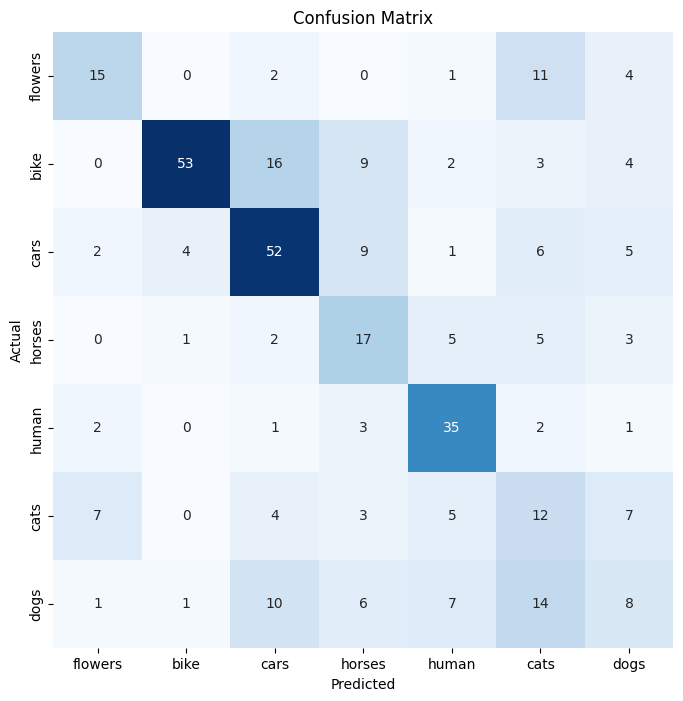

In [56]:
y_test_labels = np.argmax(y_test_encoded, axis=1)

cm = confusion_matrix(y_test_labels, predictions)

label_names = [
    'flowers',
    'bike',
    'cars',
    'horses',
    'human',
    'cats',
    'dogs'
]

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
    cmap=plt.cm.Blues
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [61]:
misses = np.where(y_test_labels != predictions)[0]

print(misses)

[  2   5  10  14  15  17  19  20  22  23  27  28  32  38  40  41  47  48
  51  52  53  54  55  57  59  60  67  68  69  73  76  77  80  82  85  86
  88  90  93  96  97  98 100 101 105 106 107 110 111 113 115 118 120 123
 124 126 128 129 131 137 138 139 140 141 142 146 147 149 150 151 152 153
 155 156 158 159 160 161 163 164 166 167 171 173 174 178 179 182 185 186
 188 189 191 192 193 194 199 200 204 208 209 211 214 216 218 219 224 228
 230 234 236 237 238 243 244 245 247 248 252 253 255 259 262 263 266 270
 274 275 277 279 283 284 285 287 288 290 293 300 301 302 304 307 308 313
 314 315 319 320 321 322 323 324 328 332 334 338 339 341 343 345 346 348
 351 353 355 356 358 359 360]


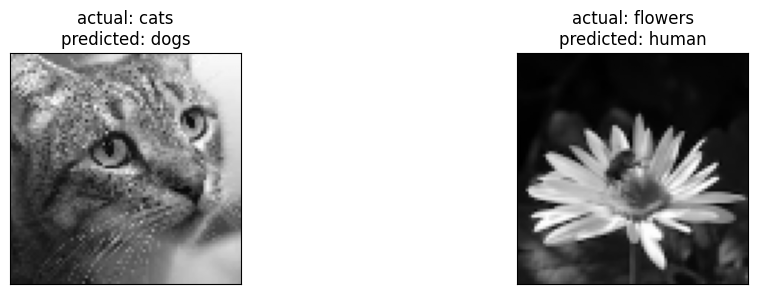

In [64]:
fig, axes = plt.subplots(ncols=2, sharex=False, figsize=(12, 3))

for i, miss in zip(range(2), misses):
    axes[i].set_title('actual: {}\npredicted: {}'
                      .format(str(label_names[y_test[miss]]),
                              str(label_names[predictions[miss]])))
    axes[i].imshow(X_test[miss], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()